# Detector de Deepfakes con ConvNeXt-V2

Este cuaderno entrena un clasificador de línea base para distinguir entre imágenes de rostros/objetos reales e imágenes generadas por IA.

Usaremos el entorno kernel **`Redes`** que has configurado previamente, el cual debería contar con las versiones `Nightly/Preview` necesarias de PyTorch o estar configurado para compilar kernels bajo demanda para aprovechar todo el poder de la arquitectura **Blackwell (RTX 5060)**.


In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder
from tqdm import tqdm
import time
import warnings
warnings.filterwarnings('ignore') # Ocultar alertas de compatibilidad si usamos compilación JIT

# Configurar dispositivo para EXPRIMIR tu RTX 5060 (8GB VRAM)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    print(f"🚀 Excelente: GPU detectada -> {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ Revisa el Kernel. La GPU no fue detectada.")

print(f"Entrenando usando: {device}")


🚀 Excelente: GPU detectada -> NVIDIA GeForce RTX 5060 Laptop GPU
Entrenando usando: cuda


## 1. Definición de Rutas y Transformaciones
Primero, prepararemos las transformaciones de imágenes para el conjunto de datos de DeepDetect-2025. Redimensionaremos todo a $224 \times 224$ píxeles y aplicaremos Data Augmentation básico para mejorar la generalización.

In [2]:
# Rutas (Asegúrate de que coincida con tus descargas de kagglehub)
DATA_DIR = r"D:\proyectos\Detector de ia\dataset_deepdetect\ddata"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")

# ¡Aumentamos el Batch Size, tienes 8 GB de VRAM dedicados a esto!
BATCH_SIZE = 64

# Transformaciones (Pre-procesamiento)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print(f"✅ Transformaciones definidas. Batch Size configurado al máximo recomendado: {BATCH_SIZE}")


✅ Transformaciones definidas. Batch Size configurado al máximo recomendado: 64


## 2. Carga y Visión General del Dataset
Utilizaremos `ImageFolder` de `TorchVision`, el cual infiere automáticamente las etiquetas "Fake" y "Real" basadas en el nombre de la carpeta.

In [3]:
print("[*] Cargando las imágenes... Esto puede tardar debido a la gran cantidad de datos.")
train_dataset = ImageFolder(TRAIN_DIR, transform=train_transform)
test_dataset = ImageFolder(TEST_DIR, transform=test_transform)

# Creamos los DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
print(f"📦 Total imágenes entrenamiento: {len(train_dataset)}")
print(f"📦 Total imágenes prueba: {len(test_dataset)}")
print(f"🏷️ Clases detectadas: {class_names}")


[*] Cargando las imágenes... Esto puede tardar debido a la gran cantidad de datos.
📦 Total imágenes entrenamiento: 90409
📦 Total imágenes prueba: 21776
🏷️ Clases detectadas: ['fake', 'real']


## 3. Preparación del Modelo ConvNeXt V2 (Tiny)
Importaremos el modelo con los pesos preentrenados en ImageNet y modificaremos el clasificador final para que arroje un resultado binario: Real o Fake (0 o 1).

In [4]:
print("🤖 Descargando / Preparando el modelo ConvNeXt V2 Tiny...")
model = models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.DEFAULT)

# Modificar la última capa (Clasificador)
num_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(num_features, len(class_names))

# Mover el modelo a la CPU (o GPU si estuviera soportada sin errores)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)

print("✅ Modelo listo para entrenar.")


🤖 Descargando / Preparando el modelo ConvNeXt V2 Tiny...
✅ Modelo listo para entrenar.


## 4. Ciclo de Entrenamiento y Guardado de Pesos (Checkpoints)
Dado que usaremos la potencia de tu GPU para entrenar, es importante **guardar el estado del modelo (los pesos)** después de cada época. Esto evitará perder progreso si se interrumpe y nos permitirá elegir la mejor versión después del entrenamiento.

In [7]:
EPOCHS = 5  # Empezamos con 5 épocas fuertes ahora que hay GPU de verdad
CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True) # Creamos carpeta para guardar versiones

# Activamos Automatic Mixed Precision (AMP) para la RTX 5060
# Esto permite entrenar al DOBLE de velocidad gastando MITAD de la VRAM (usa tensores Float16)
scaler = torch.cuda.amp.GradScaler() if device.type == 'cuda' else None

def train_model():
    best_acc = 0.0
    
    for epoch in range(EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        
        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Entrenando]")
        for images, labels in loop:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            
            # Autocast: El secreto para exprimir las gráficas modernas
            if scaler:
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                # Backpropagation escalado
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
            
            # Perfilando Estadísticas
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
            loop.set_postfix({"Loss": f"{running_loss/total:.4f}", "Acc": f"{(correct/total)*100:.2f}%"})
            
        print(f"\n[*] Epoch {epoch+1} finalizado. Evaluando modelo...")
        val_acc = evaluate_model()
        
        # 💾 GUARDAR EL CHECKPOINT AQUÍ
        checkpoint_path = os.path.join(CHECKPOINT_DIR, f"convnext_epoch{epoch+1}_acc{val_acc:.1f}.pth")
        torch.save(model.state_dict(), checkpoint_path)
        print(f"💾 Pesos guardados en: {checkpoint_path}")
        
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "convnext_best.pth"))
            print(f"🌟 ¡Nuevo mejor modelo guardado (best.pth)!")

def evaluate_model():
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc="[Validación]"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            
            # Activarlo también en testeo para acelerar
            with torch.autocast(device_type='cuda', dtype=torch.float16) if device.type == 'cuda' else torch.no_grad():
                outputs = model(images)
            
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    val_acc = (correct/total)*100
    print(f"✅ ==> Precisión en Validación: {val_acc:.2f}%\n")
    return val_acc

# ---- Para correr el entrenamiento, ejecuta el bloque
# train_model()


Epoch 1/5 [Entrenando]: 100%|██████████| 1413/1413 [14:40<00:00,  1.60it/s, Loss=0.0007, Acc=98.39%]



[*] Epoch 1 finalizado. Evaluando modelo...


[Validación]: 100%|██████████| 341/341 [02:06<00:00,  2.69it/s]


✅ ==> Precisión en Validación: 59.87%



Epoch 2/5 [Entrenando]: 100%|██████████| 1413/1413 [13:36<00:00,  1.73it/s, Loss=0.0002, Acc=99.63%]


...

✅ ==> Precisión en Validación: 52.84%



Epoch 5/5 [Entrenando]: 100%|██████████| 1413/1413 [22:29<00:00,  1.05it/s, Loss=0.0001, Acc=99.76%]   



[*] Epoch 5 finalizado. Evaluando modelo...


[Validación]: 100%|██████████| 341/341 [02:00<00:00,  2.84it/s]

✅ ==> Precisión en Validación: 50.30%



## 5. Inferencia: ¡Probando el detector!
Entrenar está muy bien, pero ¿de qué sirve si no vemos cómo clasifica el modelo una imagen nueva? Aquí tomaremos una imagen al azar de nuestra carpeta de validación, se la pasaremos al modelo y visualizaremos tanto la imagen como el veredicto final (Real o Fake).

## 4.5 Cargar Pesos Guardados (Opcional)
Si ya has entrenado tu modelo en el pasado, no necesitas volver a ejecutar la celda de la Sección 4. Puedes simplemente cargar la mejor versión de los pesos que se guardó.

In [9]:
# Cambia 'convnext_best.pth' por el nombre del archivo de época que desees cargar
archivo_pesos = "checkpoints/convnext_best.pth"

if os.path.exists(archivo_pesos):
    model.load_state_dict(torch.load(archivo_pesos, map_location=device))
    print(f"📥 Pesos de versión anterior cargados con éxito desde: {archivo_pesos}")
else:
    print(f"⚠️ No se encontró el archivo de pesos: {archivo_pesos}. Se usará el modelo en su estado actual.")


⚠️ No se encontró el archivo de pesos: checkpoints/convnext_best.pth. Se usará el modelo en su estado actual.


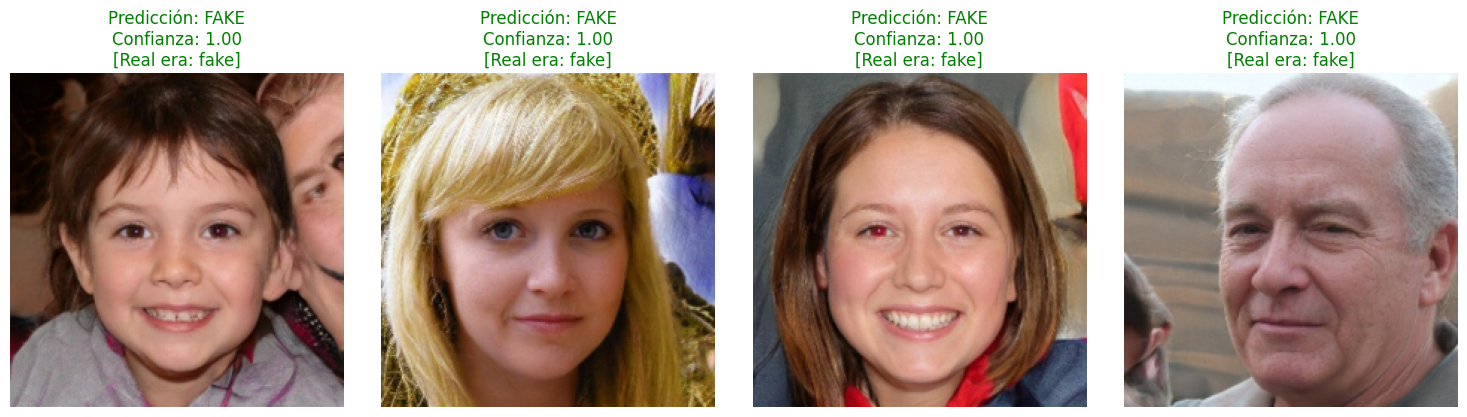

In [22]:
import matplotlib.pyplot as plt
import random
import numpy as np

def visualizar_prediccion(num_imagenes=4):
    model.eval()
    fig, axes = plt.subplots(1, num_imagenes, figsize=(15, 4))
    
    # Extraer un pequeño lote de validación
    data_iter = iter(test_loader)
    images, labels = next(data_iter)
    
    # Tomar índices aleatorios del lote
    indices = random.sample(range(len(images)), num_imagenes)
    
    with torch.no_grad():
        for i, idx in enumerate(indices):
            img = images[idx].unsqueeze(0).to(device) # Añadir dimensión extra (Batch=1)
            real_label = class_names[labels[idx].item()]
            
            # Predicción con modelo
            if device.type == 'cuda':
                with torch.autocast(device_type='cuda', dtype=torch.float16):
                    outputs = model(img)
            else:
                outputs = model(img)
                
            probabilidades = torch.nn.functional.softmax(outputs, dim=1)
            confianza, pred = torch.max(probabilidades, 1)
            pred_label = class_names[pred.item()]
            
            # Des-normalizar la imagen para poder plotearla correctamente
            img_plot = images[idx].permute(1, 2, 0).numpy()
            img_plot = img_plot * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
            img_plot = np.clip(img_plot, 0, 1)
            
            axes[i].imshow(img_plot)
            color = "green" if pred_label == real_label else "red"
            
            axes[i].set_title(f"Predicción: {pred_label.upper()}\nConfianza: {confianza.item():.2f}\n[Real era: {real_label}]", color=color)
            axes[i].axis('off')

    plt.tight_layout()
    plt.show()

# Ejecuta esta celda DESPUÉS de entrenar para ver cómo rinde
visualizar_prediccion()


In [23]:
# Celda de emergencia para asegurar el progreso
import os
os.makedirs("checkpoints", exist_ok=True)
try:
    torch.save(model.state_dict(), "checkpoints/convnext_modelo_en_vivo.pth")
    print("✅ ¡Progreso salvado exitosamente desde la memoria a: checkpoints/convnext_modelo_en_vivo.pth !")
except NameError:
    print("⚠️ El modelo no estaba en memoria en este momento. Deberás volver a entrenar.")

✅ ¡Progreso salvado exitosamente desde la memoria a: checkpoints/convnext_modelo_en_vivo.pth !
